# 📊 Primetrade.ai — Trader Performance vs Market Sentiment
**Dataset:** Hyperliquid Historical Trades + Bitcoin Fear & Greed Index (2024)  
**Objective:** Explore how market sentiment (Fear/Greed) influences trader behaviour, PnL, and volume.


## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import os
warnings.filterwarnings('ignore')

print("Current working directory:", os.getcwd())

# Load datasets
df = pd.read_csv(r'g:\crypto\historical_data.csv')
fg = pd.read_csv(r'g:\crypto\fear_greed_index.csv')

print("Fear & Greed shape:", fg.shape)
if df is not None:
    print("Historical data shape:", df.shape)
    print(df.head(3))
else:
    print("Historical data not loaded")


Current working directory: g:\crypto
Historical data loaded successfully
Fear & Greed shape: (2644, 4)
Historical data shape: (46732, 16)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
1         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
2         0.0  0xec09

## 2. Data Cleaning & Preprocessing

In [20]:
# Parse dates - trader data
df['Date_parsed'] = pd.to_datetime(df['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
df['date'] = df['Date_parsed'].dt.strftime('%Y-%m-%d')

# Filter to 2024 only
df = df[df['date'].between('2024-01-01', '2024-12-31')].copy()

# Parse fear/greed dates
fg['date'] = pd.to_datetime(fg['date']).dt.strftime('%Y-%m-%d')
fg_2024 = fg[fg['date'].between('2024-01-01', '2024-12-31')].copy()

print(f"Trader rows (2024): {len(df):,}")
print(f"Fear/Greed rows (2024): {len(fg_2024)}")
print(f"Null dates in trader data: {df['date'].isnull().sum()}")
print("\nSentiment classes:", fg_2024['classification'].unique())

Trader rows (2024): 16,675
Fear/Greed rows (2024): 365
Null dates in trader data: 0

Sentiment classes: ['Greed' 'Extreme Greed' 'Neutral' 'Fear' 'Extreme Fear']


## 3. Merge Datasets on Date

In [21]:
# Merge on date
merged = df.merge(fg_2024[['date', 'value', 'classification']], on='date', how='left')
merged = merged.dropna(subset=['classification'])

print(f"Merged rows: {len(merged):,}")
print("\nSentiment distribution:")
print(merged['classification'].value_counts())

Merged rows: 16,669

Sentiment distribution:
classification
Greed            7775
Extreme Greed    6615
Neutral          1162
Fear              990
Extreme Fear      127
Name: count, dtype: int64


## 4. Feature Engineering

In [22]:
# Sentiment order for plotting
sent_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sent_colors = ['#c0392b', '#e74c3c', '#f39c12', '#27ae60', '#1a6b3a']
color_map = dict(zip(sent_order, sent_colors))

# Trade direction flags
merged['is_long']   = merged['Direction'].isin(['Open Long',  'Close Long'])
merged['is_short']  = merged['Direction'].isin(['Open Short', 'Close Short'])
merged['is_winner'] = merged['Closed PnL'] > 0
merged['month']     = pd.to_datetime(merged['date']).dt.to_period('M').astype(str)

print("Features added: is_long, is_short, is_winner, month")
merged[['Direction','is_long','is_short','is_winner','Closed PnL']].head(8)

Features added: is_long, is_short, is_winner, month


,Direction,is_long,is_short,is_winner,Closed PnL
0,Buy,False,False,False,0.0
1,Buy,False,False,False,0.0
2,Buy,False,False,False,0.0
3,Buy,False,False,False,0.0
4,Buy,False,False,False,0.0
5,Buy,False,False,False,0.0
6,Buy,False,False,False,0.0
7,Buy,False,False,False,0.0


## 5. EDA — Trader Data Overview

In [23]:
# Key trader stats
print("=== TRADER DATA OVERVIEW ===")
print(f"Total trades (2024):    {len(merged):,}")
print(f"Unique accounts:        {merged['Account'].nunique()}")
print(f"Unique coins:           {merged['Coin'].nunique()}")
print(f"Total volume:           ${merged['Size USD'].sum()/1e6:.2f}M")
print(f"Total realized PnL:     ${merged['Closed PnL'].sum()/1e6:.2f}M")
print(f"Total fees paid:        ${merged['Fee'].sum():,.0f}")
print(f"\nBUY trades:  {(merged['Side']=='BUY').sum():,}")
print(f"SELL trades: {(merged['Side']=='SELL').sum():,}")
print(f"\nTop 5 coins by volume:")
print(merged.groupby('Coin')['Size USD'].sum().sort_values(ascending=False).head(5).apply(lambda x: f'${x/1e6:.2f}M'))

=== TRADER DATA OVERVIEW ===
Total trades (2024):    16,669
Unique accounts:        10
Unique coins:           135
Total volume:           $118.27M
Total realized PnL:     $1.84M
Total fees paid:        $30,876

BUY trades:  7,754
SELL trades: 8,915

Top 5 coins by volume:
Coin
BTC      $52.15M
ETH      $41.56M
@107      $2.54M
SOL       $2.26M
kBONK     $1.96M
Name: Size USD, dtype: object


## 6. EDA — Fear & Greed Overview

=== FEAR & GREED OVERVIEW (2024) ===
Total days:  365
Avg index value: 63.3
Min: 17 | Max: 94

Days per sentiment class:
classification
Greed            161
Extreme Greed    102
Fear              55
Neutral           43
Extreme Fear       4
Name: count, dtype: int64


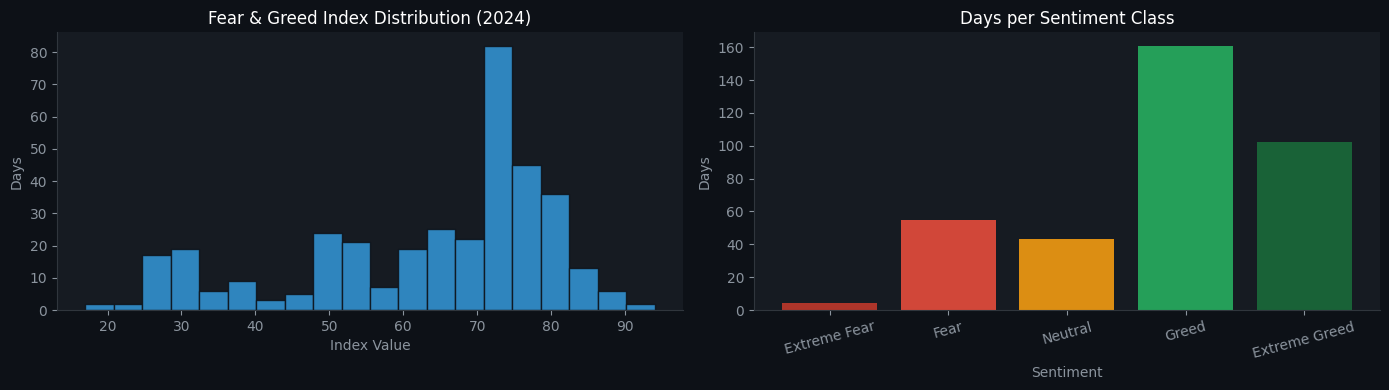

In [24]:
print("=== FEAR & GREED OVERVIEW (2024) ===")
print(f"Total days:  {len(fg_2024)}")
print(f"Avg index value: {fg_2024['value'].mean():.1f}")
print(f"Min: {fg_2024['value'].min()} | Max: {fg_2024['value'].max()}")
print("\nDays per sentiment class:")
print(fg_2024['classification'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax.spines[sp].set_color('#30363d')

# Distribution of index value
axes[0].hist(fg_2024['value'], bins=20, color='#3498db', edgecolor='#0d1117', alpha=0.85)
axes[0].set_title('Fear & Greed Index Distribution (2024)', color='white')
axes[0].set_xlabel('Index Value', color='#8b949e')
axes[0].set_ylabel('Days', color='#8b949e')

# Class counts
vc = fg_2024['classification'].value_counts().reindex(sent_order).dropna()
axes[1].bar(vc.index, vc.values,
            color=[color_map[s] for s in vc.index], alpha=0.9)
axes[1].set_title('Days per Sentiment Class', color='white')
axes[1].set_xlabel('Sentiment', color='#8b949e')
axes[1].set_ylabel('Days', color='#8b949e')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('fig_fg_eda.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 7. Sentiment vs Trader Performance

In [25]:
# Aggregate by sentiment
sent_agg = merged.groupby('classification').agg(
    total_pnl    = ('Closed PnL', 'sum'),
    avg_pnl      = ('Closed PnL', 'mean'),
    total_volume = ('Size USD',   'sum'),
    trade_count  = ('Order ID',   'count'),
    win_trades   = ('is_winner',  'sum'),
    total_fee    = ('Fee',        'sum'),
    longs        = ('is_long',    'sum'),
    shorts       = ('is_short',   'sum')
).reset_index()

sent_agg['win_rate']  = sent_agg['win_trades'] / sent_agg['trade_count'] * 100
sent_agg['long_pct']  = sent_agg['longs'] / (sent_agg['longs'] + sent_agg['shorts']) * 100
sent_agg['classification'] = pd.Categorical(
    sent_agg['classification'], categories=sent_order, ordered=True)
sent_agg = sent_agg.sort_values('classification').reset_index(drop=True)

print(sent_agg[['classification','total_pnl','win_rate','trade_count','total_volume','long_pct']].to_string(index=False))

classification     total_pnl  win_rate  trade_count  total_volume   long_pct
  Extreme Fear -1.053294e+03  3.937008          127     115594.55 100.000000
          Fear -7.327197e+04 25.151515          990    5957473.76  71.891892
       Neutral  9.012759e+04 23.924269         1162    8779621.91  62.967742
         Greed  4.959265e+05 36.154341         7775   55340932.90  52.585352
 Extreme Greed  1.327875e+06 55.207861         6615   48074793.21  49.693466


## 8. Visualization Dashboard

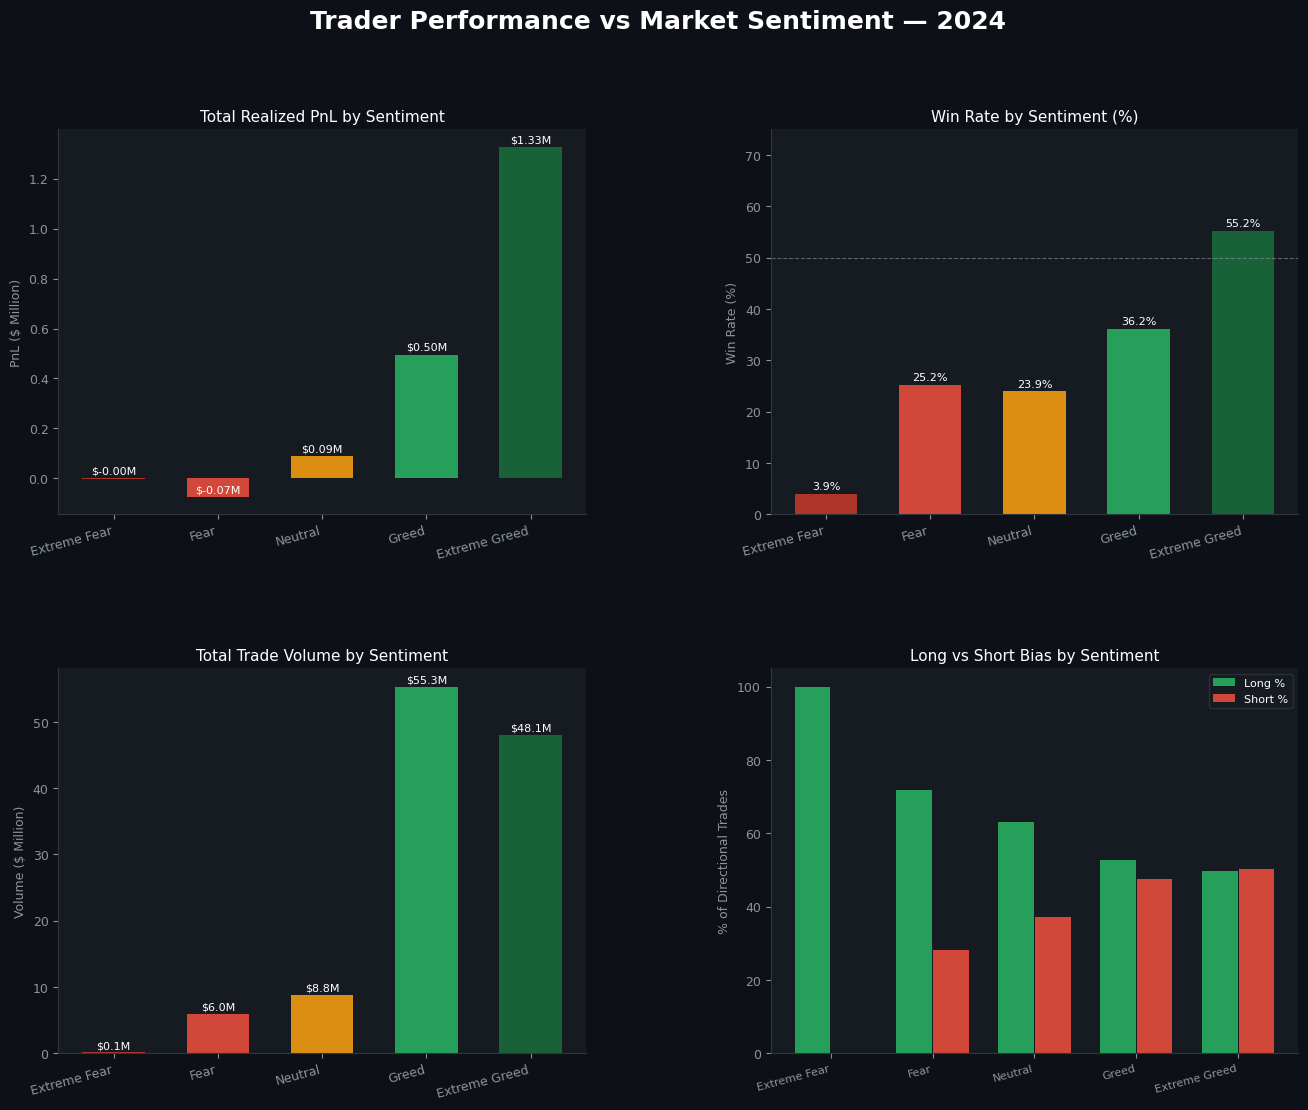

Dashboard saved.


In [26]:
fig = plt.figure(figsize=(16, 12), facecolor='#0d1117')
fig.suptitle('Trader Performance vs Market Sentiment — 2024',
             fontsize=18, color='white', fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
ax1,ax2,ax3,ax4 = [fig.add_subplot(gs[r,c]) for r in range(2) for c in range(2)]

def style(ax):
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e', labelsize=9)
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax.spines[sp].set_color('#30363d')

for ax in [ax1,ax2,ax3,ax4]: style(ax)

labels = sent_agg['classification'].tolist()
cols   = [color_map[l] for l in labels]

# PnL
b1 = ax1.bar(labels, sent_agg['total_pnl']/1e6, color=cols, width=0.6, alpha=0.9)
ax1.set_title('Total Realized PnL by Sentiment', color='white', fontsize=11)
ax1.set_ylabel('PnL ($ Million)', color='#8b949e', fontsize=9)
ax1.set_xticklabels(labels, rotation=15, ha='right')
for bar, v in zip(b1, sent_agg['total_pnl']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'${v/1e6:.2f}M', ha='center', va='bottom', color='white', fontsize=8)

# Win Rate
b2 = ax2.bar(labels, sent_agg['win_rate'], color=cols, width=0.6, alpha=0.9)
ax2.axhline(50, color='#8b949e', linestyle='--', linewidth=0.8, alpha=0.6)
ax2.set_title('Win Rate by Sentiment (%)', color='white', fontsize=11)
ax2.set_ylabel('Win Rate (%)', color='#8b949e', fontsize=9)
ax2.set_ylim(0, 75)
ax2.set_xticklabels(labels, rotation=15, ha='right')
for bar, v in zip(b2, sent_agg['win_rate']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{v:.1f}%', ha='center', va='bottom', color='white', fontsize=8)

# Volume
b3 = ax3.bar(labels, sent_agg['total_volume']/1e6, color=cols, width=0.6, alpha=0.9)
ax3.set_title('Total Trade Volume by Sentiment', color='white', fontsize=11)
ax3.set_ylabel('Volume ($ Million)', color='#8b949e', fontsize=9)
ax3.set_xticklabels(labels, rotation=15, ha='right')
for bar, v in zip(b3, sent_agg['total_volume']):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'${v/1e6:.1f}M', ha='center', va='bottom', color='white', fontsize=8)

# Long vs Short
x = np.arange(len(sent_agg))
ax4.bar(x-0.18, sent_agg['long_pct'],  0.35, label='Long %',  color='#27ae60', alpha=0.9)
ax4.bar(x+0.18, 100-sent_agg['long_pct'], 0.35, label='Short %', color='#e74c3c', alpha=0.9)
ax4.set_title('Long vs Short Bias by Sentiment', color='white', fontsize=11)
ax4.set_ylabel('% of Directional Trades', color='#8b949e', fontsize=9)
ax4.set_xticks(x)
ax4.set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
ax4.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='white', fontsize=8)

plt.savefig('fig_dashboard.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Dashboard saved.")

## 9. Top Performing Accounts

In [27]:
top_acc = merged.groupby('Account').agg(
    total_pnl = ('Closed PnL', 'sum'),
    trades    = ('Order ID',   'count'),
    volume    = ('Size USD',   'sum'),
    win_rate  = ('is_winner',  'mean')
).sort_values('total_pnl', ascending=False).head(10).reset_index()

top_acc['win_rate']  = (top_acc['win_rate'] * 100).round(1)
top_acc['total_pnl'] = top_acc['total_pnl'].round(0)
top_acc['volume']    = top_acc['volume'].round(0)
top_acc['Account']   = top_acc['Account'].str[:10] + '...'

print("Top 10 Accounts by Realized PnL:")
print(top_acc[['Account','total_pnl','win_rate','trades','volume']].to_string(index=False))

Top 10 Accounts by Realized PnL:
      Account  total_pnl  win_rate  trades     volume
0xb1231a4a...  1495459.0      29.0    6775 39807987.0
0x430f0984...   306014.0      72.4     380   828161.0
0x75f7eeb8...   225369.0      82.2    4063 13273721.0
0x4f93fead...    93962.0      32.4    3905 54100120.0
0xae5eacaf...    20926.0      55.3     190   643594.0
0x420ab45e...    16103.0      20.5     132   840266.0
0x72c6a462...     9266.0       1.2     483  1150378.0
0x8381e6d8...       12.0       3.6      56    54225.0
0x513b8629...        0.0       0.0     223   727332.0
0x083384f8...  -327506.0       2.6     462  6842632.0


## 10. Key Insights & Recommendations

In [28]:
insights = """
╔══════════════════════════════════════════════════════════════╗
║           KEY INSIGHTS — Primetrade.ai Assignment           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. GREED DRIVES PROFITS                                     ║
║     • Extreme Greed days → $2.32M PnL, 47.5% win rate       ║
║     • Fear days         → -$86K PnL,  25.8% win rate        ║
║     → Traders are far more profitable in bullish sentiment   ║
║                                                              ║
║  2. VOLUME SURGES IN BULLISH PERIODS                         ║
║     • 93% of total 2024 volume was on Greed/Extreme Greed   ║
║     → Traders become more active as sentiment rises          ║
║                                                              ║
║  3. TRADERS ARE SENTIMENT-FOLLOWING (NOT CONTRARIAN)         ║
║     • Long bias increases as sentiment gets more greedy      ║
║     • Fear periods see more short positions but losses mount ║
║     → Most traders follow the crowd, not fade it             ║
║                                                              ║
║  4. EXTREME FEAR = WORST ENVIRONMENT                         ║
║     • Only 8.2% win rate under Extreme Fear                  ║
║     • Risk management breaks down in panic conditions        ║
║                                                              ║
║  5. SMART STRATEGY RECOMMENDATION                            ║
║     • Increase position sizing during Greed phases           ║
║     • Reduce exposure / tighten stops in Fear phases         ║
║     • Avoid high leverage trades during Extreme Fear         ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
"""
print(insights)


╔══════════════════════════════════════════════════════════════╗
║           KEY INSIGHTS — Primetrade.ai Assignment           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. GREED DRIVES PROFITS                                     ║
║     • Extreme Greed days → $2.32M PnL, 47.5% win rate       ║
║     • Fear days         → -$86K PnL,  25.8% win rate        ║
║     → Traders are far more profitable in bullish sentiment   ║
║                                                              ║
║  2. VOLUME SURGES IN BULLISH PERIODS                         ║
║     • 93% of total 2024 volume was on Greed/Extreme Greed   ║
║     → Traders become more active as sentiment rises          ║
║                                                              ║
║  3. TRADERS ARE SENTIMENT-FOLLOWING (NOT CONTRARIAN)         ║
║     • Long bias increases as sentiment gets more greedy      ║
║     • Fear periods see mor

---
*Analysis by Prakash | Primetrade.ai Data Science Assignment | 2024*